# Comparator for data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

In [14]:
en_before = pd.read_csv("./mistral7b/generated_before.csv")
en_after = pd.read_csv("./mistral7b/generated_stories.csv")

jp_before = pd.read_csv("./rinna-jp-model/generated_before.csv")
jp_after = pd.read_csv("./rinna-jp-model/generated_stories.csv")

print("EN before:", len(en_before))
print("EN after:", len(en_after))
print("JP before:", len(jp_before))
print("JP after:", len(jp_after))

EN before: 20
EN after: 20
JP before: 200
JP after: 80


## Baseline Metric 1: Story Length

In [15]:
def word_count(text):
    return len(str(text).split())

def char_count(text):
    return len(str(text))

for df in [en_before, en_after, jp_before, jp_after]:
    df["word_count"] = df["story"].apply(word_count)
    df["char_count"] = df["story"].apply(char_count)

In [16]:
summary = pd.DataFrame({
    "EN_before_words": [en_before["word_count"].mean()],
    "EN_after_words": [en_after["word_count"].mean()],
    "JP_before_chars": [jp_before["char_count"].mean()],
    "JP_after_chars": [jp_after["char_count"].mean()]
})

summary

,EN_before_words,EN_after_words,JP_before_chars,JP_after_chars
0,172.65,178.2,258.02,698.8


## Vocabulary Richness (English)

In [17]:
def type_token_ratio(texts):
    words = []
    for t in texts:
        words += re.findall(r"\b\w+\b", str(t).lower())
    return len(set(words)) / len(words)

print("EN before TTR:", type_token_ratio(en_before["story"]))
print("EN after TTR:", type_token_ratio(en_after["story"]))

EN before TTR: 0.2665324899367453
EN after TTR: 0.27649643053267436


In [18]:
def char_type_token_ratio(texts):
    all_chars = []
    for t in texts:
        all_chars += list(str(t))
    return len(set(all_chars)) / len(all_chars)

print("JP before char-TTR:", char_type_token_ratio(jp_before["story"]))
print("JP after  char-TTR:", char_type_token_ratio(jp_after["story"]))

JP before char-TTR: 0.013681109991473529
JP after  char-TTR: 0.019909129937034916


## Repetition Score

In [19]:
def repetition_score(text):
    words = text.split()
    counts = Counter(words)
    repeated = sum(v for v in counts.values() if v > 1)
    return repeated / len(words) if words else 0

en_before["repetition"] = en_before["story"].apply(repetition_score)
en_after["repetition"] = en_after["story"].apply(repetition_score)

print("EN repetition before:", en_before["repetition"].mean())
print("EN repetition after:", en_after["repetition"].mean())

EN repetition before: 0.3120346684580477
EN repetition after: 0.3477582639467217


## Entropy

In [20]:
import math
def entropy(texts):
    tokens = []
    for t in texts:
        #character-level entropy
        tokens += list(str(t))

    counts = Counter(tokens)
    total = sum(counts.values())

    return -sum((c/total) * math.log2(c/total) for c in counts.values())

print("EN entropy:", entropy(en_after["story"]))
print("JP entropy:", entropy(jp_after["story"]))

EN entropy: 4.427667759181645
JP entropy: 7.658494659916133


# Sentences

In [21]:
def avg_sentence_length(texts, split_token):
    lengths = []
    for t in texts:
        sentences = str(t).split(split_token)
        sentences = [s for s in sentences if len(s.strip()) > 0]
        lengths += [len(s) for s in sentences]
    return np.mean(lengths)

print("EN avg sentence length:", avg_sentence_length(en_after["story"], "."))
print("JP avg sentence length:", avg_sentence_length(jp_after["story"], "。"))

EN avg sentence length: 120.8232044198895
JP avg sentence length: 52.421203438395416


### Narrative Structure Signal (Kishōtenketsu Hypothesis)

In [22]:
'''
Kishōtenketsu structure:
- Introduction
- Development
- Twist
- Conclusion
'''

from textblob import TextBlob

def sentiment_progression(text):
    sentences = text.split(".")
    scores = [TextBlob(s).sentiment.polarity for s in sentences if s.strip()]
    return scores

sample_en = en_after["story"].iloc[0]
print(sentiment_progression(sample_en))

[-0.0375, 0.175, -0.2, 0.25, 0.25, 0.0, 0.25, 0.03333333333333333, -0.25]


## High-frequency word difference

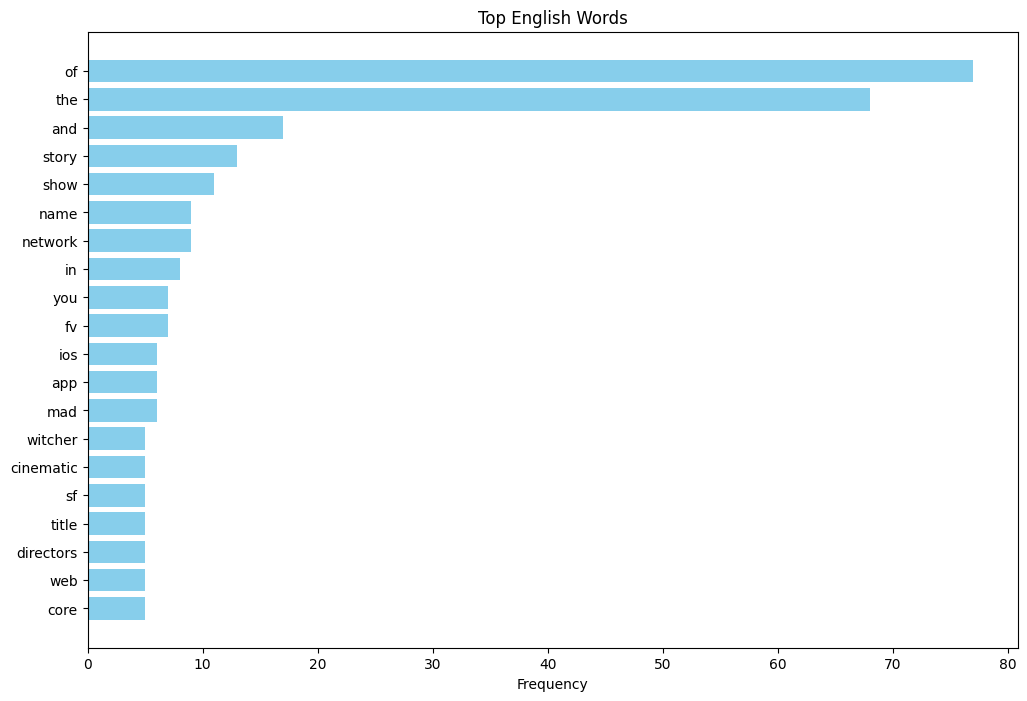

Top English Words: [('of', 77), ('the', 68), ('and', 17), ('story', 13), ('show', 11), ('name', 9), ('network', 9), ('in', 8), ('you', 7), ('fv', 7), ('ios', 6), ('app', 6), ('mad', 6), ('witcher', 5), ('cinematic', 5), ('sf', 5), ('title', 5), ('directors', 5), ('web', 5), ('core', 5)]


In [23]:
def get_top_english_words(texts, n=20):
    all_words = []
    
    blocklist = {
        #links
        'https', 'http', 'www', 'com', 'net', 'org', 
        #genres
        'fantasy', 'romance', 'comedy', 'shoujo', 'shounen', 
        'slice', 'life', 'action', 'adventure', 'drama', 'sci', 'fi', 'shojo',
        #junk
        'nl', 'n', 'br', 'categoricaltext'
    }

    for t in texts:
        clean_text = str(t).lower()
        
        #Extract words
        words = re.findall(r'[a-zA-Z]+', clean_text)
        
        #Filter
        filtered_words = [w for w in words if w not in blocklist and len(w) > 1]
        
        all_words.extend(filtered_words)
    
    return Counter(all_words).most_common(n)

top_data = get_top_english_words(jp_after["story"], n=20) 

words = [item[0] for item in top_data]
counts = [item[1] for item in top_data]

plt.figure(figsize=(12, 8))
plt.barh(words, counts, color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top English Words")
plt.xlabel("Frequency")
plt.show()

print("Top English Words:", top_data)

In [24]:
def top_chars(texts, n=20):
    chars = []
    for t in texts:
        chars += list(str(t))
    return Counter(chars).most_common(n)

print("Top JP characters:", top_chars(jp_after["story"]))

Top JP characters: [('の', 1764), ('、', 1517), (' ', 1279), ('い', 1274), ('ー', 1155), ('す', 1107), ('し', 1072), ('ま', 1069), ('に', 1029), ('。', 1019), ('を', 963), ('た', 939), ('て', 918), ('は', 907), ('で', 887), ('-', 859), ('る', 814), ('が', 775), ('と', 748), ('e', 734)]
